In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB0
from sklearn.metrics import confusion_matrix, classification_report

print(f"TensorFlow version: {tf.__version__}")

# ── Verificar GPU ─────────────────────────────────────────────────────────────
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"✅ Usando GPU: {gpus[0].name}")
    tf.config.experimental.set_memory_growth(gpus[0], True)
else:
    print("⚠️  GPU no encontrada, usando CPU")

TensorFlow version: 2.18.1
✅ Usando GPU: /physical_device:GPU:0


In [ ]:
TRAIN_DIR   = '/workspace/dataset/train/'
TEST_DIR    = '/workspace/dataset/test/'

IMG_SIZE    = 224
BATCH_SIZE  = 32
EPOCHS      = 100
LR          = 1e-5
DROPOUT     = 0.2
PATIENCE    = 5
VAL_SPLIT   = 0.2
SEED        = 123
AUTOTUNE    = tf.data.AUTOTUNE

# Subconjunto para pruebas rápidas (poner None para usar el dataset completo)
TRAIN_SAMPLES = None
TEST_SAMPLES  = None

In [ ]:
train_ds_full = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels='inferred',
    label_mode='int',
    color_mode='rgb',
    batch_size=BATCH_SIZE,
    seed=SEED,
    validation_split=VAL_SPLIT,
    subset='training'
)

val_ds_full = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels='inferred',
    label_mode='int',
    color_mode='rgb',
    batch_size=BATCH_SIZE,
    seed=SEED,
    validation_split=VAL_SPLIT,
    subset='validation'
)

test_ds_full = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    labels='inferred',
    label_mode='int',
    color_mode='rgb',
    batch_size=BATCH_SIZE,
    seed=SEED
)

class_names = train_ds_full.class_names
print(f"Clases detectadas: {class_names}")

# Subconjunto para pruebas rápidas
if TRAIN_SAMPLES:
    train_ds = train_ds_full.take(TRAIN_SAMPLES // BATCH_SIZE + 1)
    val_ds   = val_ds_full.take((TRAIN_SAMPLES // 4) // BATCH_SIZE + 1)
else:
    train_ds = train_ds_full
    val_ds   = val_ds_full

if TEST_SAMPLES:
    test_ds = test_ds_full.take(TEST_SAMPLES // BATCH_SIZE + 1)
else:
    test_ds = test_ds_full

print(f"Batches — train: {len(train_ds)}, val: {len(val_ds)}, test: {len(test_ds)}")

Found 47874 files belonging to 2 classes.
Using 38300 files for training.


I0000 00:00:1780494215.580933    7421 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 19275 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4090, pci bus id: 0000:01:00.0, compute capability: 8.9


Found 47874 files belonging to 2 classes.
Using 9574 files for validation.
Found 11965 files belonging to 2 classes.
Clases detectadas: ['fake', 'real']
Batches — train: 1197, val: 300, test: 374


In [ ]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
], name="data_augmentation")

def resize_only(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    return image, label

def resize_and_augment(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = data_augmentation(image, training=True)
    return image, label

train_ds = (
    train_ds
    .map(resize_and_augment, num_parallel_calls=AUTOTUNE)
    #.cache()
    .prefetch(buffer_size=AUTOTUNE)
)

val_ds = (
    val_ds
    .map(resize_only, num_parallel_calls=AUTOTUNE)
    .cache()
    .prefetch(buffer_size=AUTOTUNE)
)

test_ds = (
    test_ds
    .map(resize_only, num_parallel_calls=AUTOTUNE)
    .cache()
    .prefetch(buffer_size=AUTOTUNE)
)

# Verificación: rango de píxeles
image_batch, labels_batch = next(iter(train_ds))
print(f"Rango de píxeles → min: {np.min(image_batch):.1f}, max: {np.max(image_batch):.1f}")
print(f"Shape del batch: {image_batch.shape}")
print(f"Etiquetas del batch: {labels_batch.numpy()[:8]}")

2026-06-03 13:43:37.238029: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: CANCELLED: RecvAsync is cancelled.
	 [[{{node data_augmentation_1/random_rotation_1/ReadVariableOp/_12}}]] [type.googleapis.com/tensorflow.DerivedStatus='']
2026-06-03 13:43:37.238114: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: CANCELLED: RecvAsync is cancelled.
	 [[{{node data_augmentation_1/random_rotation_1/ReadVariableOp/_12}}]]
	 [[data_augmentation_1/random_zoom_1/Add/_20]] [type.googleapis.com/tensorflow.DerivedStatus='']


Rango de píxeles → min: 0.0, max: 255.0
Shape del batch: (32, 224, 224, 3)
Etiquetas del batch: [0 0 1 0 1 1 0 1]


In [ ]:
def build_model(img_size: int = IMG_SIZE, dropout_rate: float = DROPOUT,
                learning_rate: float = LR) -> keras.Model:
    """
    EfficientNetB0 con cabeza de clasificación binaria.
    backbone.trainable = False → solo se entrena la cabeza.
    """
    inputs = layers.Input(shape=(img_size, img_size, 3))

    base_model = EfficientNetB0(
        include_top=False,
        weights='imagenet',
        input_shape=(img_size, img_size, 3)
    )
    base_model.trainable = False

    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D(name="avg_pool")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout_rate, name="top_dropout")(x)
    outputs = layers.Dense(1, activation="sigmoid", name="pred")(x)

    model = keras.Model(inputs, outputs, name="EfficientNet")

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )
    return model


model = build_model()
model.summary()

trainable_params = sum(
    np.prod(v.shape) for v in model.trainable_weights
)
total_params = sum(
    np.prod(v.shape) for v in model.weights
)
print(f"\nParámetros entrenables: {trainable_params:,} / {total_params:,} "
      f"({100 * trainable_params / total_params:.1f}%)")

Model: "EfficientNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ avg_pool                        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ top_dropout (Dropout)           │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pred (Dense)                    │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,055,972 (15.47 MB)

 Trainable params: 3,841 (15.00 KB)

 Non-trainable params: 4,052,131 (15.46 MB)


Parámetros entrenables: 3,841 / 4,055,972.0 (0.1%)


In [ ]:
callbacks = [
    # Guarda el mejor modelo según val_auc
    keras.callbacks.ModelCheckpoint(
        "best_model_cnn_finetuning.keras",
        monitor="val_auc",
        save_best_only=True,
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_auc",
        patience=PATIENCE,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_auc",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    ),
]

hist = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    callbacks=callbacks
)

Epoch 1/100


I0000 00:00:1780494222.895133    7645 service.cc:148] XLA service 0x7f5134112b30 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780494222.896150    7645 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce RTX 4090, Compute Capability 8.9
2026-06-03 13:43:46.575924: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1780494230.682679    7645 cuda_dnn.cc:529] Loaded cuDNN version 91002
E0000 00:00:1780494233.301594    7645 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1780494233.381932    7645 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1780494233.569621    7645

 109/1197 ━━━━━━━━━━━━━━━━━━━━ 2:03 113ms/step - accuracy: 0.6520 - auc: 0.7000 - loss: 0.7105

2026-06-03 13:44:08.763337: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile


 125/1197 ━━━━━━━━━━━━━━━━━━━━ 2:07 119ms/step - accuracy: 0.6589 - auc: 0.7091 - loss: 0.6987

...

1101/1197 ━━━━━━━━━━━━━━━━━━━━ 18s 188ms/step - accuracy: 0.8336 - auc: 0.9154 - loss: 0.3694

Corrupt JPEG data: premature end of data segment


1124/1197 ━━━━━━━━━━━━━━━━━━━━ 13s 188ms/step - accuracy: 0.8336 - auc: 0.9154 - loss: 0.3694

2026-06-03 15:28:45.459314: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile


1197/1197 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step - accuracy: 0.8337 - auc: 0.9153 - loss: 0.3695
Epoch 28: val_auc did not improve from 0.93728
1197/1197 ━━━━━━━━━━━━━━━━━━━━ 225s 187ms/step - accuracy: 0.8344 - auc: 0.9147 - loss: 0.3707 - val_accuracy: 0.8665 - val_auc: 0.9370 - val_loss: 0.3250 - learning_rate: 1.5625e-05
Epoch 28: early stopping
Restoring model weights from the end of the best epoch: 23.


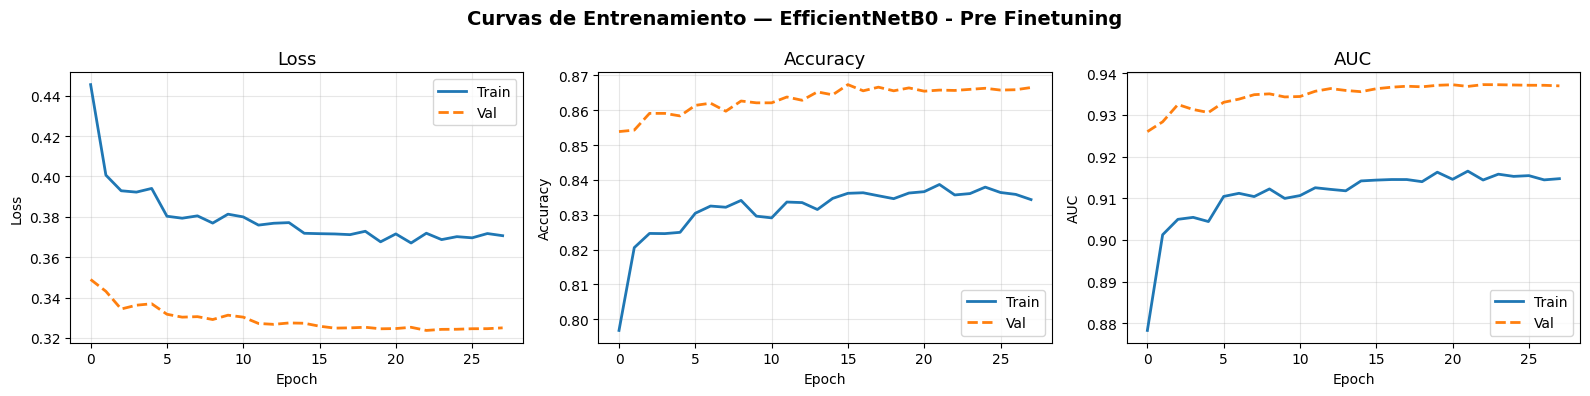

In [8]:
def plot_history(hist, figure_name, figure_title):
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    metrics = [
        ('loss',     'Loss',     'Loss'),
        ('accuracy', 'Accuracy', 'Accuracy'),
        ('auc',      'AUC',      'AUC'),
    ]
    for ax, (key, title, ylabel) in zip(axes, metrics):
        ax.plot(hist.history[key],     label='Train', linewidth=2)
        ax.plot(hist.history[f'val_{key}'], label='Val', linewidth=2, linestyle='--')
        ax.set_title(title, fontsize=13)
        ax.set_xlabel('Epoch')
        ax.set_ylabel(ylabel)
        ax.legend()
        ax.grid(True, alpha=0.3)
    plt.suptitle('Curvas de Entrenamiento — EfficientNetB0 - Pre Finetuning', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(figure_name, dpi=150, bbox_inches='tight')
    plt.show()

fig_name = '/workspace/imagenes_metricas_full_dataset/training_curves_cnn_prefinetuning_final.png'
fig_title = 'Curvas de Entrenamiento — EfficientNetB0 - Pre Finetuning'
plot_history(hist, fig_name, fig_title)

In [9]:
print("=" * 45)
print("EVALUACIÓN FINAL SOBRE TEST SET")
print("=" * 45)
test_loss, test_acc, test_auc = model.evaluate(test_ds, verbose=1)
print(f"\nLoss:     {test_loss:.4f}")
print(f"Accuracy: {test_acc:.4f}  ({test_acc*100:.2f}%)")
print(f"AUC:      {test_auc:.4f}")

EVALUACIÓN FINAL SOBRE TEST SET
 16/374 ━━━━━━━━━━━━━━━━━━━━ 1:00 169ms/step - accuracy: 0.8653 - auc: 0.9501 - loss: 0.3020

2026-06-03 15:29:00.838273: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile


136/374 ━━━━━━━━━━━━━━━━━━━━ 39s 165ms/step - accuracy: 0.8560 - auc: 0.9370 - loss: 0.3254

Corrupt JPEG data: premature end of data segment


336/374 ━━━━━━━━━━━━━━━━━━━━ 6s 162ms/step - accuracy: 0.8570 - auc: 0.9360 - loss: 0.3273

2026-06-03 15:29:53.258505: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile


370/374 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - accuracy: 0.8571 - auc: 0.9359 - loss: 0.3274

E0000 00:00:1780500600.200713    7650 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1780500600.273730    7650 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1780500600.459442    7650 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1780500600.540666    7650 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1780500600.895881    7650 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:0

374/374 ━━━━━━━━━━━━━━━━━━━━ 64s 172ms/step - accuracy: 0.8583 - auc: 0.9350 - loss: 0.3290

Loss:     0.3290
Accuracy: 0.8583  (85.83%)
AUC:      0.9350


In [10]:
y_true_list = []
y_pred_list = []
y_prob_list = []

for x_batch, y_batch in test_ds:
    y_true_list.extend(y_batch.numpy())

    # predict_on_batch es más eficiente que predict() en un loop
    probs = model.predict_on_batch(x_batch)
    y_prob_list.extend(probs.flatten())
    y_pred_list.extend((probs > 0.5).astype(int).flatten())

y_true = np.array(y_true_list)
y_pred = np.array(y_pred_list)
y_prob = np.array(y_prob_list)

print("Distribución y_true:", np.bincount(y_true))
print("Distribución y_pred:", np.bincount(y_pred))

Distribución y_true: [5970 5995]
Distribución y_pred: [5965 6000]


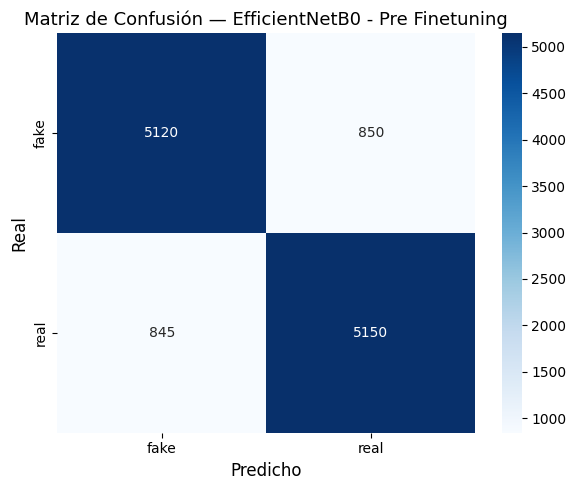


CLASSIFICATION REPORT
              precision    recall  f1-score   support

        fake       0.86      0.86      0.86      5970
        real       0.86      0.86      0.86      5995

    accuracy                           0.86     11965
   macro avg       0.86      0.86      0.86     11965
weighted avg       0.86      0.86      0.86     11965



In [11]:
# Matriz de confusión
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel('Predicho', fontsize=12)
plt.ylabel('Real', fontsize=12)
plt.title('Matriz de Confusión — EfficientNetB0 - Pre Finetuning', fontsize=13)
plt.tight_layout()
plt.savefig('/workspace/imagenes_metricas_full_dataset/confusion_matrix_cnn_prefinetuning_final.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "=" * 50)
print("CLASSIFICATION REPORT")
print("=" * 50)
print(classification_report(y_true, y_pred, target_names=class_names))

Imagen guardada como classification_report.png


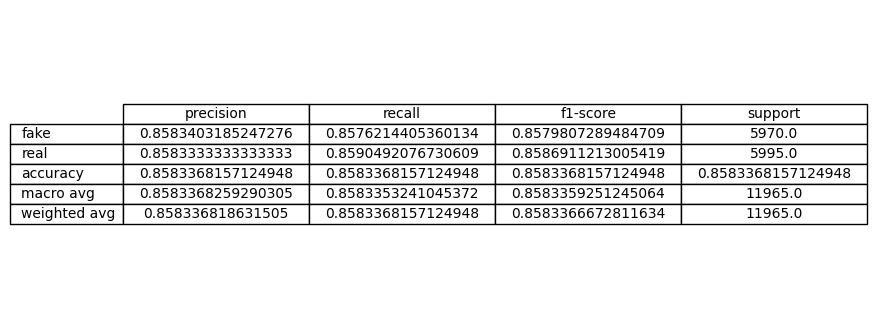

In [ ]:
report_dict = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
df_report = pd.DataFrame(report_dict).transpose()

fig, ax = plt.subplots(figsize=(8, 4))
ax.axis('off')
ax.axis('tight')

# Dibujar la tabla
table = ax.table(cellText=df_report.values, 
                 colLabels=df_report.columns, 
                 rowLabels=df_report.index, 
                 cellLoc='center', 
                 loc='center')

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.2)

plt.savefig('/workspace/imagenes_metricas_full_dataset/classification_report_cnn_prefinetuning_final.png', bbox_inches='tight', dpi=300)
print("Imagen guardada como classification_report.png")

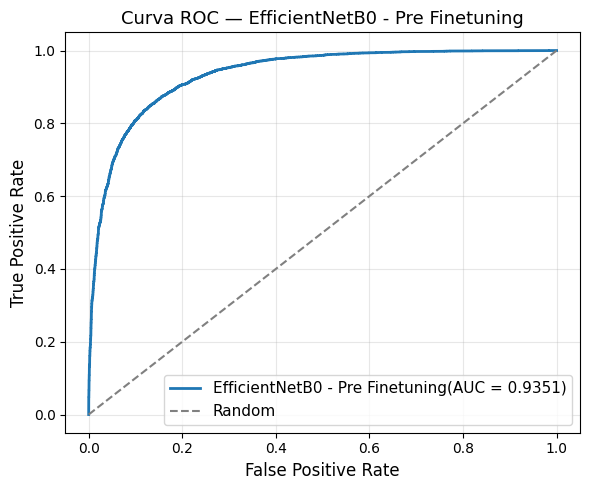

AUC final (test completo): 0.9351


In [13]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, _ = roc_curve(y_true, y_prob)
auc_score   = roc_auc_score(y_true, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, lw=2, label=f'EfficientNetB0 - Pre Finetuning(AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Curva ROC — EfficientNetB0 - Pre Finetuning', fontsize=13)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/workspace/imagenes_metricas_full_dataset/roc_curve_cnn_salida_prefinetuning_final.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"AUC final (test completo): {auc_score:.4f}")

In [ ]:
cnn_model = model.get_layer("efficientnetb0")
cnn_model.trainable = True

fine_tune_at = 200 #TODO justificar el por qué se han elegido este numero de capas

for layer in cnn_model.layers[:fine_tune_at]:
    layer.trainable = False
for layer in cnn_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

trainable = sum([1 for l in cnn_model.layers if l.trainable])
frozen   = sum([1 for l in cnn_model.layers if not l.trainable])
print(f"Capas entrenables: {trainable} | Congeladas: {frozen}")

trainable_ft = sum(np.prod(v.shape) for v in cnn_model.trainable_weights)
print(f"Parámetros entrenables en fine-tuning: {trainable_ft:,}")

callbacks_ft = [
    keras.callbacks.ModelCheckpoint(
        "best_model_finetuned.keras",
        monitor="val_auc",
        save_best_only=True,
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_auc",
        patience=PATIENCE,
        restore_best_weights=True,
        verbose=1
    ),
]

Capas entrenables: 30 | Congeladas: 208
Parámetros entrenables en fine-tuning: 2,037,520


In [ ]:
hist_ft = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    callbacks=callbacks_ft
)

print("\n=" * 45)
print("EVALUACIÓN FINAL TRAS FINE-TUNING")
print("=" * 45)
model.evaluate(test_ds)

Epoch 1/100
 115/1197 ━━━━━━━━━━━━━━━━━━━━ 3:27 191ms/step - accuracy: 0.8519 - auc: 0.9317 - loss: 0.3342

2026-06-03 15:33:22.054564: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile


 132/1197 ━━━━━━━━━━━━━━━━━━━━ 3:20 188ms/step - accuracy: 0.8519 - auc: 0.9317 - loss: 0.3342

2026-06-03 15:33:24.950765: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile


 186/1197 ━━━━━━━━━━━━━━━━━━━━ 3:11 190ms/step - accuracy: 0.8524 - auc: 0.9315 - loss: 0.3345

...

Corrupt JPEG data: premature end of data segment


1126/1197 ━━━━━━━━━━━━━━━━━━━━ 13s 189ms/step - accuracy: 0.9686 - auc: 0.9958 - loss: 0.0833

2026-06-03 18:32:43.639018: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile


1196/1197 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step - accuracy: 0.9687 - auc: 0.9958 - loss: 0.0833
Epoch 48: val_auc did not improve from 0.98074
1197/1197 ━━━━━━━━━━━━━━━━━━━━ 226s 188ms/step - accuracy: 0.9692 - auc: 0.9958 - loss: 0.0831 - val_accuracy: 0.9252 - val_auc: 0.9805 - val_loss: 0.2078
Epoch 48: early stopping
Restoring model weights from the end of the best epoch: 43.

=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
EVALUACIÓN FINAL TRAS FINE-TUNING
374/374 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9260 - auc: 0.9805 - loss: 0.2044


[0.2043849676847458, 0.9260342717170715, 0.9805423021316528]

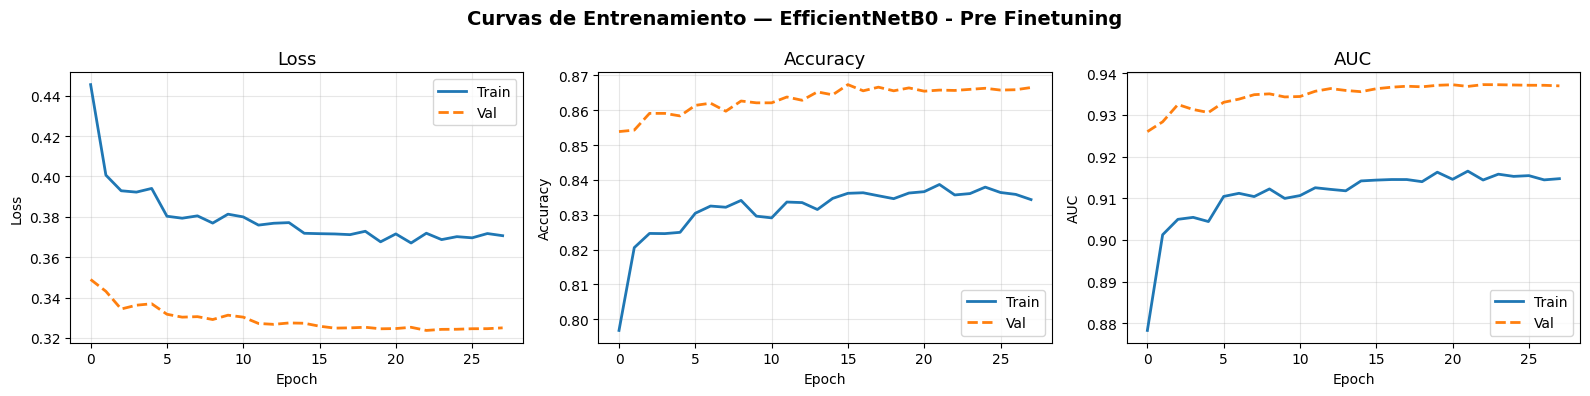

In [17]:
fig_name = '/workspace/imagenes_metricas_full_dataset/training_curves_cnn_salida_postfinetuning_final.png'
fig_title = 'Curvas de Entrenamiento — EfficientNetB0 - Post Finetuning'
plot_history(hist_ft, fig_name, fig_title)

In [18]:
print("=" * 45)
print("EVALUACIÓN DESPUES DE FINE TUNING SOBRE TEST SET")
print("=" * 45)
test_loss, test_acc, test_auc = model.evaluate(test_ds, verbose=1)
print(f"\nLoss:     {test_loss:.4f}")
print(f"Accuracy: {test_acc:.4f}  ({test_acc*100:.2f}%)")
print(f"AUC:      {test_auc:.4f}")

EVALUACIÓN DESPUES DE FINE TUNING SOBRE TEST SET
374/374 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9260 - auc: 0.9805 - loss: 0.2044

Loss:     0.2044
Accuracy: 0.9260  (92.60%)
AUC:      0.9805


In [19]:
y_true_list = []
y_pred_list = []
y_prob_list = []

for x_batch, y_batch in test_ds:
    y_true_list.extend(y_batch.numpy())

    # predict_on_batch es más eficiente que predict() en un loop
    probs = model.predict_on_batch(x_batch)
    y_prob_list.extend(probs.flatten())
    y_pred_list.extend((probs > 0.5).astype(int).flatten())

y_true = np.array(y_true_list)
y_pred = np.array(y_pred_list)
y_prob = np.array(y_prob_list)

print("Distribución y_true:", np.bincount(y_true))
print("Distribución y_pred:", np.bincount(y_pred))

Distribución y_true: [5970 5995]
Distribución y_pred: [6357 5608]


2026-06-03 18:33:11.630606: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


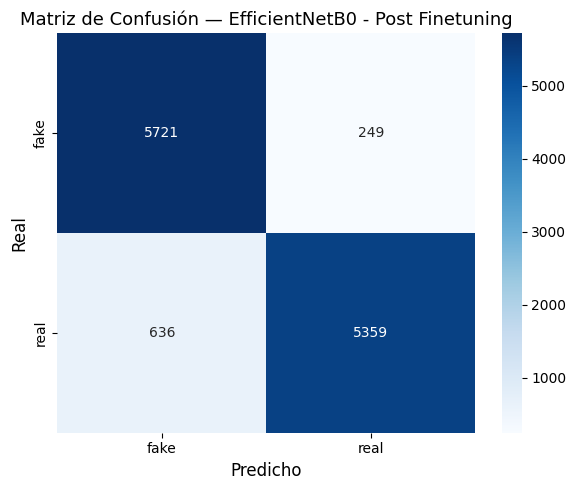


CLASSIFICATION REPORT
              precision    recall  f1-score   support

        fake       0.90      0.96      0.93      5970
        real       0.96      0.89      0.92      5995

    accuracy                           0.93     11965
   macro avg       0.93      0.93      0.93     11965
weighted avg       0.93      0.93      0.93     11965



In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel('Predicho', fontsize=12)
plt.ylabel('Real', fontsize=12)
plt.title('Matriz de Confusión — EfficientNetB0 - Post Finetuning', fontsize=13)
plt.tight_layout()
plt.savefig('/workspace/imagenes_metricas_full_dataset/confusion_matrix_cnn_postfinetuning_final.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "=" * 50)
print("CLASSIFICATION REPORT")
print("=" * 50)
print(classification_report(y_true, y_pred, target_names=class_names))

Imagen guardada como classification_report.png


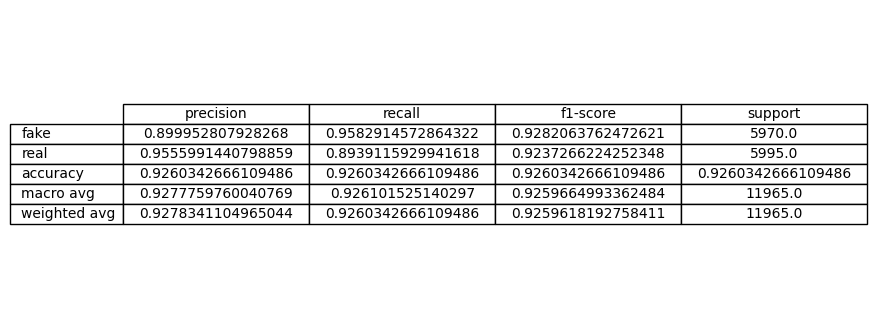

In [ ]:
report_dict = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
df_report = pd.DataFrame(report_dict).transpose()

fig, ax = plt.subplots(figsize=(8, 4))
ax.axis('off')
ax.axis('tight')

# Dibujar la tabla
table = ax.table(cellText=df_report.values, 
                 colLabels=df_report.columns, 
                 rowLabels=df_report.index, 
                 cellLoc='center', 
                 loc='center')

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.2)

plt.savefig('/workspace/imagenes_metricas_full_dataset/classification_report_cnn_postfinetuning_final.png', bbox_inches='tight', dpi=300)
print("Imagen guardada como classification_report.png")

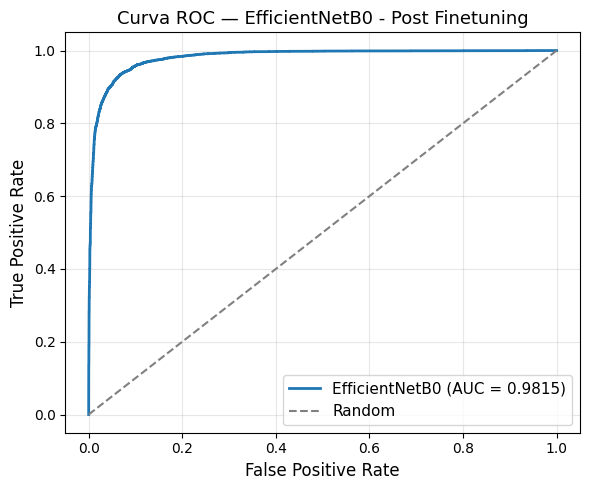

AUC final (test completo): 0.9815


In [22]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, _ = roc_curve(y_true, y_prob)
auc_score   = roc_auc_score(y_true, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, lw=2, label=f'EfficientNetB0 (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Curva ROC — EfficientNetB0 - Post Finetuning', fontsize=13)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/workspace/imagenes_metricas_full_dataset/roc_curve_cnn_postfinetuning_final.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"AUC final (test completo): {auc_score:.4f}")